# Sionna RT on Real Map

Load the generated XML/PLY scene, place TX/RX, compute ray-tracing paths with Sionna RT's official `PathSolver()`, preview rays, and generate the channel impulse response with official `paths.cir()`.

In [ ]:
from pathlib import Path
import numpy as np

from sionna.rt import PathSolver, PlanarArray, Receiver, Transmitter, load_scene

NOTEBOOK_DIR = Path("<your path to>/glb_to_rt") #Path.cwd()
SCENE_XML = NOTEBOOK_DIR / "generated_model" / "example_chongqing.xml"

# Change these two lines whenever you want to move TX/RX, then rerun this cell.
TX_POSITION = np.array([1300.0, -650.0, 350.0], dtype=np.float32)
RX_POSITION = np.array([1800.0, -850.0, 350.0], dtype=np.float32)
# WARNING: make sure Tx/Rx is higher than soil of the earth.

TX_ORIENTATION = [0.0, 0.0, 0.0]        # 朝 +X
RX_ORIENTATION = [np.pi, 0.0, 0.0]      # 朝 -X

#RX_ORIENTATION = [0.0, 0.0, 0.0]        # 朝 +X
#RX_ORIENTATION = [np.pi, 0.0, 0.0]      # 朝 -X
#RX_ORIENTATION = [np.pi/2, 0.0, 0.0]    # 朝 +Y
#RX_ORIENTATION = [-np.pi/2, 0.0, 0.0]   # 朝 -Y
#RX_ORIENTATION = [0.0, -np.pi/2, 0.0]   # 朝 +Z
#RX_ORIENTATION = [0.0, np.pi/2, 0.0]    # 朝 -Z

TX_POWER_DBM = 30.0
TX_DISPLAY_RADIUS = 120.0
RX_DISPLAY_RADIUS = 100.0
TX_COLOR = (1.0, 0.0, 0.0)  # bright red
RX_COLOR = (1.0, 0.0, 1.0)  # bright magenta

FREQUENCY = 3.5e9
BANDWIDTH = 100e6
MAX_DEPTH = 5
REFRACTION = False

PREVIEW_RESOLUTION = [1280, 720]
PREVIEW_FOV = 35.0
CLIP_AT = 1500.0
CLIP_PLANE_ORIENTATION = (0.0, 0.0, -1.0)


def compute_paths_for_positions(tx_position, rx_position):
    tx_position = np.asarray(tx_position, dtype=np.float32)
    rx_position = np.asarray(rx_position, dtype=np.float32)

    if not SCENE_XML.exists():
        raise FileNotFoundError(f"Scene XML not found: {SCENE_XML}")

    scene = load_scene(str(SCENE_XML))
    scene.frequency = FREQUENCY
    scene.bandwidth = BANDWIDTH
    #scene.tx_array = PlanarArray(num_rows=4, num_cols=4, pattern="tr38901", polarization="V")
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")

    tx = Transmitter(
        name="base_station",
        position=tx_position,
        power_dbm=TX_POWER_DBM,
        color=TX_COLOR,
        display_radius=TX_DISPLAY_RADIUS,
    )
    rx = Receiver(
        name="user_terminal",
        position=rx_position,
        color=RX_COLOR,
        display_radius=RX_DISPLAY_RADIUS,
    )
    scene.add(tx)
    scene.add(rx)
    tx.look_at(rx)

    paths = PathSolver()(scene, max_depth=MAX_DEPTH, refraction=REFRACTION)

    print(f"Scene XML: {SCENE_XML}")
    print(f"TX position: {tx_position.tolist()}")
    print(f"RX position: {rx_position.tolist()}")

    scene.preview(
        paths=paths,
        resolution=tuple(PREVIEW_RESOLUTION),
        fov=PREVIEW_FOV,
        show_devices=True,
        show_orientations=True,
        clip_at=CLIP_AT,
        clip_plane_orientation=CLIP_PLANE_ORIENTATION,
    )

    return scene, paths


scene, paths = compute_paths_for_positions(TX_POSITION, RX_POSITION)

2026-07-09 11:09:05 WARN  [PLYMesh] "example_chongqing_land_dem_precise_soil_fill.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.
Scene XML: /root/glb_to_rt/generated_model/example_chongqing.xml
TX position: [1300.0, -650.0, 350.0]
RX position: [1800.0, -850.0, 350.0]


## Channel Impulse Response

Generate the channel impulse response with Sionna RT's official `paths.cir()` function. The plotting code only visualizes the returned coefficients and delays.

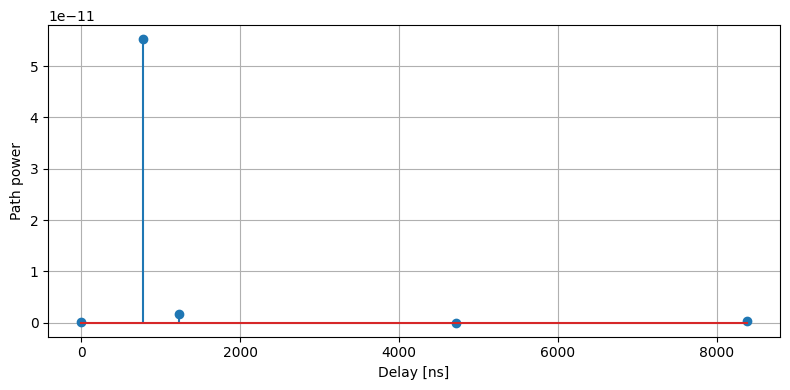

In [7]:
import matplotlib.pyplot as plt
from sionna.rt import cpx_abs_square

# Channel impulse response generated by Sionna RT.
# normalize_delays=True follows the official convention: the first arriving path is at 0 ns.
a, tau = paths.cir(normalize_delays=True)

# Compute the squared magnitude of the path coefficients.
a_abs_square = cpx_abs_square(a)

# Sum over the transmit antennas, following the official tutorial.
a_abs_square = np.sum(a_abs_square, axis=3)

# Get the path coefficients and delays in ns.
# This notebook has a single TX/RX pair, so squeezing leaves only the path dimension.
a_abs_square = np.squeeze(a_abs_square)
tau_ns = np.squeeze(tau) * 1e9
valid = np.squeeze(paths.valid.numpy())

# Only keep the valid paths.
a_abs_square = a_abs_square[valid]
tau_ns = tau_ns[valid]

# Plot the channel impulse response.
plt.figure(figsize=(8, 4))
plt.stem(tau_ns, a_abs_square)
plt.xlabel("Delay [ns]")
plt.ylabel("Path power")
plt.grid(True)
plt.tight_layout()
plt.show()